In [ ]:
!pip install pandas -q
!pip install seaborn  -q

In [128]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [140]:
df = pd.read_csv("data/compustat.csv")

print(df.shape)
print(df.head())


(620141, 58)
  costat curcdq datafmt indfmt consol     tic    datadate  gvkey  \
0      I    USD     STD   INDL      C  SERV.1  2010-01-31   1082   
1      I    USD     STD   INDL      C   AIM.1  2010-01-31   1173   
2      I    USD     STD   INDL      C   ACEL.  2010-01-31   1259   
3      A    USD     STD   INDL      C     ABM  2010-01-31   1410   
4      I    USD     STD   INDL      C    LGTY  2010-01-31   1562   

                           conm                                conml  ...  \
0                 SERVIDYNE INC                        Servidyne Inc  ...   
1                AEROSONIC CORP                       Aerosonic Corp  ...   
2      TAMIR BIOTHECHNOLOGY INC              Tamir Biotechnology Inc  ...   
3            ABM INDUSTRIES INC                   ABM Industries Inc  ...   
4  LOGILITY SPPLY CHAIN SOL INC  Logility Supply Chain Solutions Inc  ...   

    xsgaq  capxy  dltisy    dvy  oancfy  oibdpy  scstkcy    mkvaltq   prchq  \
0   2.457  0.211    0.00  0.149  -1.

In [141]:
num_companies = df['gvkey'].dropna().nunique()
print("Number of unique companies:", num_companies)

Number of unique companies: 21048


In [142]:
df['datadate'] = pd.to_datetime(df['datadate'])

min_date = df['datadate'].min()
max_date = df['datadate'].max()

print(f"Initial date in dataset: {min_date}")
print(f"Last date in dataset: {max_date}")

Initial date in dataset: 2010-01-31 00:00:00
Last date in dataset: 2025-12-31 00:00:00


In [ ]:
obs_per_firm = df.groupby('gvkey')['datadate'].count()

# Keep firms with at least 40 quarters (10 years)
valid_firms = obs_per_firm[obs_per_firm >= 12].index
df = df[df['gvkey'].isin(valid_firms)]


### Load Macro Economic Variables

In [133]:
gdp = pd.read_csv("data/GDP.csv")
gdp['observation_date'] = pd.to_datetime(gdp['observation_date'])


# Convert quarter start to quarter end
gdp['date'] = gdp['observation_date'] + pd.offsets.QuarterEnd(0)

gdp = gdp[['date', 'GDP']]
gdp = gdp.set_index('date')
gdp = gdp.sort_index()
print(gdp.shape)
print(gdp.head())

(61, 1)
                  GDP
date                 
2010-09-30  15141.607
2010-12-31  15309.474
2011-03-31  15351.448
2011-06-30  15557.539
2011-09-30  15647.680


In [134]:
rates = pd.read_csv("data/Interest rates.csv")
rates['observation_date'] = pd.to_datetime(rates['observation_date'])

rates = rates.set_index('observation_date')

# Take the last available rate in each quarter (quarter-end value)
rates_q = rates.resample('Q').last().ffill()

rates_q.rename(columns={'INTDSRUSM193N': 'interest_rate'}, inplace=True)

print(rates_q.shape)
print(rates_q.head())

(63, 1)
                  IRLTLT01USQ156N
observation_date                 
2010-06-30               3.490000
2010-09-30               2.786667
2010-12-31               2.863333
2011-03-31               3.460000
2011-06-30               3.210000


C:\Users\manoj\AppData\Local\Temp\ipykernel_9364\2194733773.py:7: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  rates_q = rates.resample('Q').last().ffill()


In [135]:
treasury = pd.read_csv("data/crisp treasury and inflation.csv")
treasury['caldt'] = pd.to_datetime(treasury['caldt'])

treasury = treasury.set_index('caldt')

treasury_q = treasury[['b10ret', 't90ret', 'cpiret']]
#Return on a 10-year Treasury bond index; Return on a 90-day Treasury bill index;  Return on a 10-year Treasury bond index; 
print(treasury_q.shape)
treasury_q.head()

(44, 3)


,b10ret,t90ret,cpiret
caldt,,,
2014-03-31,0.036126,0.000222,0.013920
2014-06-30,0.025191,0.000124,0.008676
2014-09-30,0.007790,0.000116,-0.001309
2014-12-31,0.028963,0.000036,-0.013523
2015-03-31,0.024583,0.000091,0.005566


In [136]:
crsp = pd.read_csv("data/crisp indices.csv")
crsp['QTDATE'] = pd.to_datetime(crsp['QTDATE'])

crsp = crsp.set_index('QTDATE')

# Convert monthly to quarterly mean
crsp_q = crsp.resample('Q').mean()

crsp_q = crsp_q[['YLDMAT']]
print(crsp_q.shape)
crsp_q.head()

(44, 1)


C:\Users\manoj\AppData\Local\Temp\ipykernel_9364\4137765293.py:7: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  crsp_q = crsp.resample('Q').mean()


,YLDMAT
QTDATE,
2014-03-31,1.543000
2014-06-30,1.511667
2014-09-30,1.583000
2014-12-31,1.415333
2015-03-31,1.324667


In [137]:
import pandas as pd
import numpy as np

# 1️⃣ Create full quarterly date range
dates = pd.date_range(
    start="2014-03-31",
    end="2024-12-31",
    freq="Q"
)

# 2️⃣ Create empty dataframe
macro = pd.DataFrame(index=dates)

# 3️⃣ For each dataset, match nearest date instead of NaN
for df in [gdp, rates_q, treasury_q, crsp_q]:
    
    # Make sure index is sorted (required for nearest)
    df = df.sort_index()
    
    # Reindex to quarterly dates using nearest match
    df_nearest = df.reindex(dates, method="nearest")
    
    # Add columns manually (no join used)
    for col in df_nearest.columns:
        macro[col] = df_nearest[col].values

# 4️⃣ Sort index
macro = macro.sort_index()

print(macro.head())

C:\Users\manoj\AppData\Local\Temp\ipykernel_9364\3590641848.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  dates = pd.date_range(


                  GDP  IRLTLT01USQ156N    b10ret    t90ret    cpiret    YLDMAT
2014-03-31  17197.738         2.763333  0.036126  0.000222  0.013920  1.543000
2014-06-30  17518.508         2.623333  0.025191  0.000124  0.008676  1.511667
2014-09-30  17804.228         2.496667  0.007790  0.000116 -0.001309  1.583000
2014-12-31  17912.079         2.280000  0.028963  0.000036 -0.013523  1.415333
2015-03-31  18063.529         1.966667  0.024583  0.000091  0.005566  1.324667


In [138]:
macro.to_csv("data/macro.csv", index=True)

### select one firm

In [144]:
selected_gvkey = valid_firms[0]  
firm_df = df[df['gvkey'] == selected_gvkey].copy()

firm_df['datadate'] = pd.to_datetime(df['datadate'])
firm_df = firm_df.set_index('datadate').sort_index()

In [145]:
min_date = firm_df.index.min()
max_date = firm_df.index.max()

print(f"Minimum date: {min_date}")
print(f"Maximum date: {max_date}")

Minimum date: 2010-02-28 00:00:00
Maximum date: 2025-11-30 00:00:00


In [ ]:
def add_macro_variables(df, gdp, rates_q, treasury_q, crsp_q):
    
    start_date = pd.to_datetime("2014-03-31")
    end_date   = pd.to_datetime("2024-12-31")
    
    df = df.loc[start_date:end_date].copy()
    
    for df in [gdp, rates_q, treasury_q, crsp_q]:
        df = df.sort_index()
        df_nearest = df.reindex(df.index, method="nearest")
        
        for col in df_nearest.columns:
            df[col] = df_nearest[col].values
    
    return df

In [ ]:

def train_test_split_ts(df, target_col='cheq', test_size=4):
    train = df.iloc[:-test_size]
    test  = df.iloc[-test_size:]
    
    y_train = train[target_col]
    y_test  = test[target_col]
    
    X_train = train.drop(columns=[target_col])
    X_test  = test.drop(columns=[target_col])
    
    return X_train, X_test, y_train, y_test

In [148]:
from sklearn.impute import KNNImputer

def prepare_features(X_train, X_test, impute=False):
    # Remove columns with >20% missing
    missing_ratio = X_train.isnull().mean()
    cols_to_keep = missing_ratio[missing_ratio <= 0.20].index
    
    X_train = X_train[cols_to_keep]
    X_test  = X_test[cols_to_keep]
    
    # Keep numeric only
    X_train = X_train.select_dtypes(include=['number'])
    X_test  = X_test[X_train.columns]
    
    if impute:
        imputer = KNNImputer(n_neighbors=5)
        X_train = imputer.fit_transform(X_train)
        X_test  = imputer.transform(X_test)
    
    return X_train, X_test

In [149]:
import numpy as np

# break data into 5 parts and check stationary

n_parts = 5
part_size = len(y_train) // n_parts

means = []
variances = []

for i in range(n_parts):
    start = i * part_size
    end = (i + 1) * part_size if i < n_parts - 1 else len(y_train)
    
    segment = y_train.iloc[start:end]
    means.append(segment.mean())
    variances.append(segment.var())

for i in range(n_parts):
    print(f"Part {i+1}: Mean = {means[i]:.3f}, Variance = {variances[i]:.3f}")

Part 1: Mean = 68.114, Variance = 499.061
Part 2: Mean = 21.143, Variance = 235.330
Part 3: Mean = 40.043, Variance = 55.170
Part 4: Mean = 134.286, Variance = 17160.231
Part 5: Mean = 60.209, Variance = 240.383


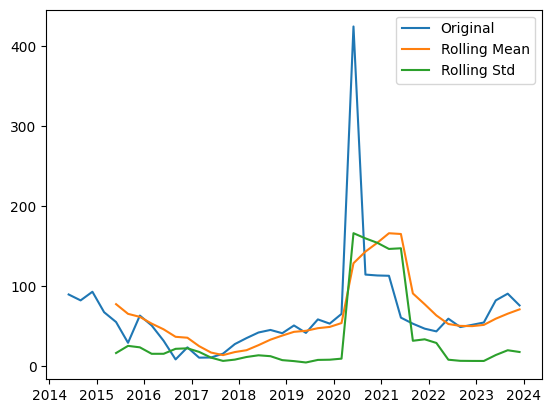

In [150]:
import pandas as pd
import matplotlib.pyplot as plt

rolling_mean = y_train.rolling(window=5).mean()
rolling_std = y_train.rolling(window=5).std()

plt.plot(y_train, label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.show()

In [151]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF
adf_result = adfuller(y_train)
print("ADF p-value:", adf_result[1])

# KPSS
from statsmodels.tsa.stattools import kpss
kpss_stat, p_value, _, _ = kpss(y_train)
print("KPSS p-value:", p_value)

ADF p-value: 0.00015658807383803834
KPSS p-value: 0.1


C:\Users\manoj\AppData\Local\Temp\ipykernel_9364\1110373166.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, _, _ = kpss(y_train)


### remove nonstationary traits

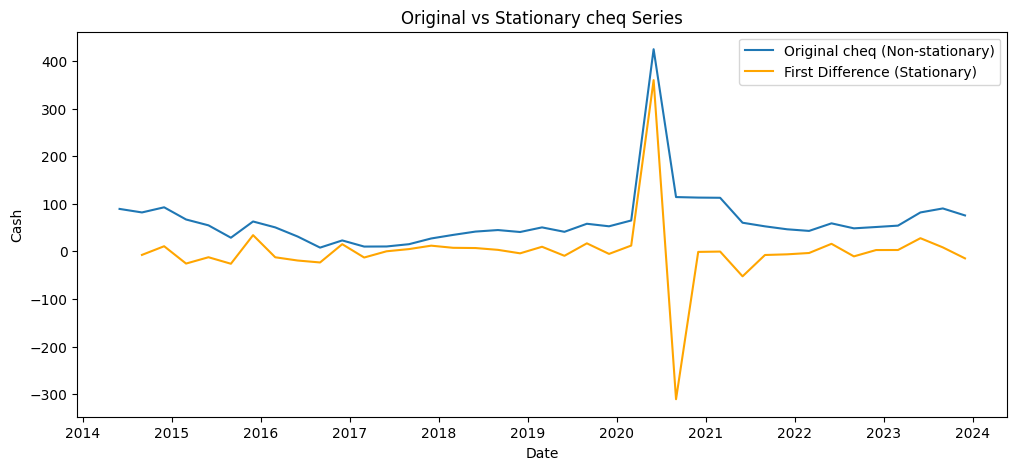

In [152]:
import pandas as pd
import matplotlib.pyplot as plt

cheq_original = y_train.copy()
cheq_stationary = y_train.diff().dropna()

plt.figure(figsize=(12,5))

plt.plot(cheq_original.index, cheq_original, label='Original cheq (Non-stationary)')
plt.plot(cheq_stationary.index, cheq_stationary, label='First Difference (Stationary)', color='orange')

plt.title('Original vs Stationary cheq Series')
plt.xlabel('Date')
plt.ylabel('Cash')
plt.legend()
plt.show()

### fit arima

In [153]:

def run_arima(y_train, y_test, title_suffix=""):
    
    model = ARIMA(y_train, order=(1,1,1))
    model_fit = model.fit()
    
    forecast = model_fit.forecast(steps=len(y_test))
    forecast.index = y_test.index
    
    # Plot
    plt.figure(figsize=(12,5))
    
    plt.plot(y_train.index, y_train, label="Training Data")
    plt.plot(y_test.index, y_test, label="Actual (Test)", color="green")
    plt.plot(forecast.index, forecast, label="ARIMA Forecast",
             color="red", linestyle="--")
    
    plt.title(f"ARIMA Forecast vs Actual {title_suffix}")
    plt.xlabel("Date")
    plt.ylabel("Cash (cheq)")
    plt.legend()
    plt.gcf().autofmt_xdate()
    plt.show()


In [154]:
def run_pipeline(firm_df,
                 use_macro=False,
                 impute=False,
                 gdp=None,
                 rates_q=None,
                 treasury_q=None,
                 crsp_q=None):
    
    df = firm_df.copy()
    
    if use_macro:
        df = add_macro_variables(df, gdp, rates_q, treasury_q, crsp_q)
    
    X_train, X_test, y_train, y_test = train_test_split_ts(df)
    
    X_train, X_test = prepare_features(X_train, X_test, impute=impute)
    
    label = f"(Macro={use_macro}, Impute={impute})"
    
    run_arima(y_train, y_test, title_suffix=label)


c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-NOV will be used.
  self._init_dates(dates, freq)
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-NOV will be used.
  self._init_dates(dates, freq)
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-NOV will be used.
  self._init_dates(dates, freq)


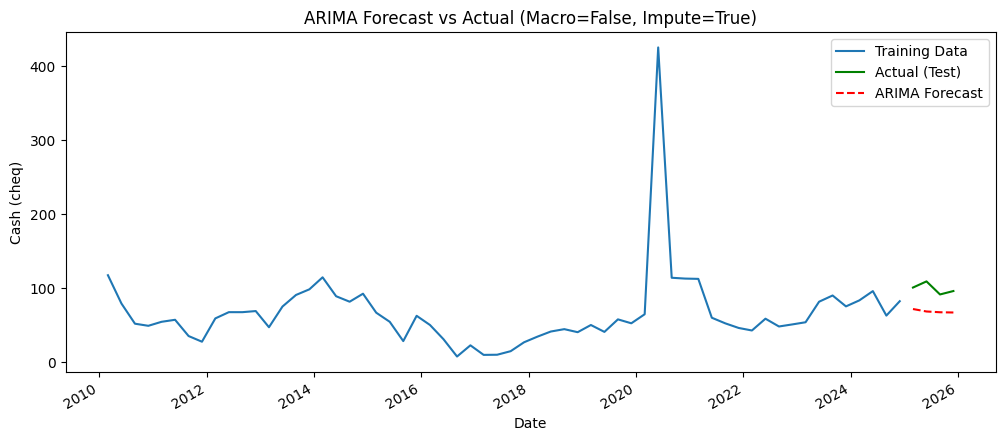

In [158]:
# 1️⃣ No Macro, No Imputation
run_pipeline(firm_df,
             impute=True,
             use_macro=False)


c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-NOV will be used.
  self._init_dates(dates, freq)
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-NOV will be used.
  self._init_dates(dates, freq)
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-NOV will be used.
  self._init_dates(dates, freq)


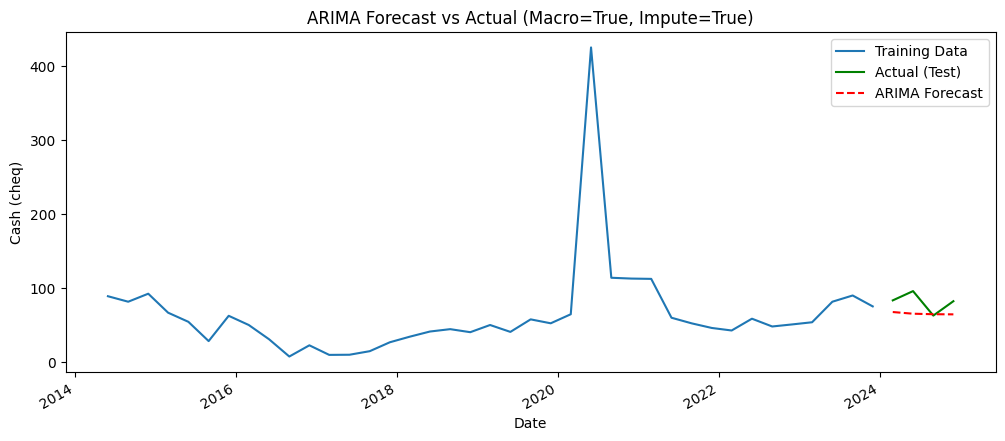

In [157]:
# 4️⃣ With Macro, With Imputation
run_pipeline(firm_df,
             use_macro=True,
             impute=True,
             gdp=gdp,
             rates_q=rates_q,
             treasury_q=treasury_q,
             crsp_q=crsp_q)